# 02 - Analyse statistique exploratoire

## Objectif
Ce notebook vise à :
- décrire les distributions des variables,
- analyser les relations entre variables,
- étudier les tendances temporelles,
- explorer les comportements clients et produits,
- réaliser quelques tests statistiques simples.

In [ ]:
# Cette cellule importe les bibliothèques nécessaires à l'analyse statiistique.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency

pd.set_option("display.max_columns", None)

In [3]:
# Cette cellule charge les données nettoyées.

df_client = pd.read_csv("clean_client.csv")
df_produit = pd.read_csv("clean_produit.csv")
df_vente = pd.read_csv("clean_vente.csv")
df_depence = pd.read_csv("clean_depence.csv")
df_budget = pd.read_csv("clean_budget.csv")

In [4]:
# Cette cellule convertit les dates pour les analyses temporelles.

df_vente["date"] = pd.to_datetime(df_vente["date"], errors="coerce")
df_depence["date"] = pd.to_datetime(df_depence["date"], errors="coerce")
df_budget["month"] = pd.to_datetime(df_budget["month"], errors="coerce")
df_client["created_date"] = pd.to_datetime(df_client["created_date"], errors="coerce")

In [6]:
# Cette cellule vérifie les bornes temporelles des données.

print("Ventes :", df_vente["date"].min(), "->", df_vente["date"].max())
print("Dépenses :", df_depence["date"].min(), "->", df_depence["date"].max())
print("Budget :", df_budget["month"].min(), "->", df_budget["month"].max())

Ventes : 2019-01-01 00:00:00 -> 2025-12-31 00:00:00
Dépenses : 2019-01-01 00:00:00 -> 2025-12-31 00:00:00
Budget : 2019-01-01 00:00:00 -> 2025-12-01 00:00:00


## Interprétation
Cette étape permet de confirmer la période d’analyse.

À commenter :
- les jeux de données doivent couvrir des périodes cohérentes ;
- si les bornes temporelles sont différentes, certaines comparaisons peuvent être biaisées ;
- la présence de trous temporels peut limiter l’analyse des tendances.

Statistiques descriptives

In [7]:
# Cette cellule affiche les statistiques descriptives.

print("Ventes ")
display(df_vente.describe(include="all"))

print("Dépenses ")
display(df_depence.describe(include="all"))

Ventes 


,date,invoice_id,customer_id,product_id,qty,unit_price_eur,discount_rate,total_eur,currency,payment_terms_days
count,26121,26121,26121,26121,26121.000000,26121.000000,26121.000000,26121.000000,26121,26121.000000
unique,NaN,26121,120,35,NaN,NaN,NaN,NaN,1,NaN
top,NaN,INV00000001,C0074,P010,NaN,NaN,NaN,NaN,EUR,NaN
freq,NaN,1,257,804,NaN,NaN,NaN,NaN,26121,NaN
mean,2022-07-05 01:47:29.982772480,NaN,NaN,NaN,2.140309,444.655667,0.072080,884.765424,NaN,27.676008
min,2019-01-01 00:00:00,NaN,NaN,NaN,1.000000,91.990000,0.000000,69.790000,NaN,0.000000
25%,2020-10-08 00:00:00,NaN,NaN,NaN,1.000000,151.140000,0.036800,294.260000,NaN,15.000000
50%,2022-06-29 00:00:00,NaN,NaN,NaN,2.000000,389.570000,0.069900,567.830000,NaN,30.000000
75%,2024-04-06 00:00:00,NaN,NaN,NaN,3.000000,609.820000,0.103900,1127.820000,NaN,30.000000
max,2025-12-31 00:00:00,NaN,NaN,NaN,10.000000,1216.680000,0.250000,9157.410000,NaN,60.000000


Dépenses 


,expense_id,date,category,department,vendor,amount_mad,currency,type,account_code,account_label
count,4852,4852,4852,4852,4852,4852.000000,4852,4852,4852.000000,4852
unique,4852,NaN,10,6,15,NaN,1,2,NaN,10
top,EXP000000001,NaN,Software,Operations,Office landlord,NaN,MAD,Variable,NaN,Compte Software
freq,1,NaN,656,1743,400,NaN,4852,4474,NaN,656
mean,NaN,2022-07-06 03:06:58.466611456,NaN,NaN,NaN,3144.137894,NaN,NaN,6005.188788,NaN
min,NaN,2019-01-01 00:00:00,NaN,NaN,NaN,50.000000,NaN,NaN,6000.000000,NaN
25%,NaN,2020-10-13 00:00:00,NaN,NaN,NaN,514.935000,NaN,NaN,6003.000000,NaN
50%,NaN,2022-07-06 00:00:00,NaN,NaN,NaN,983.735000,NaN,NaN,6005.000000,NaN
75%,NaN,2024-04-01 00:00:00,NaN,NaN,NaN,1522.932500,NaN,NaN,6007.000000,NaN
max,NaN,2025-12-31 00:00:00,NaN,NaN,NaN,64082.820000,NaN,NaN,6009.000000,NaN


## Interprétation
Les statistiques descriptives permettent d’avoir une première lecture de la distribution des variables.

À commenter :
- la moyenne et la médiane permettent d’évaluer la symétrie ;
- un écart important entre moyenne et médiane suggère une asymétrie ;
- les min/max aident à repérer d’éventuelles valeurs aberrantes.

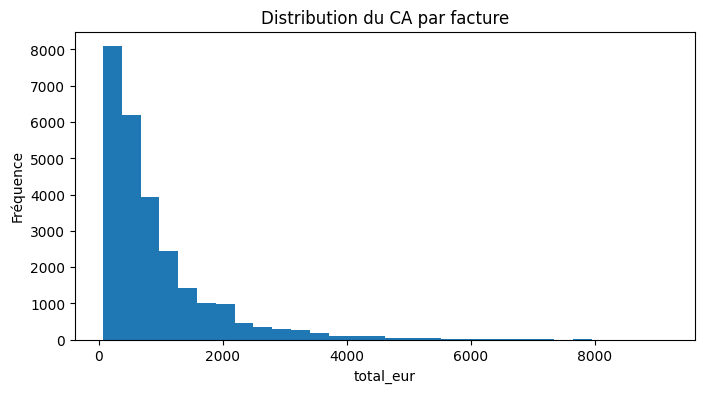

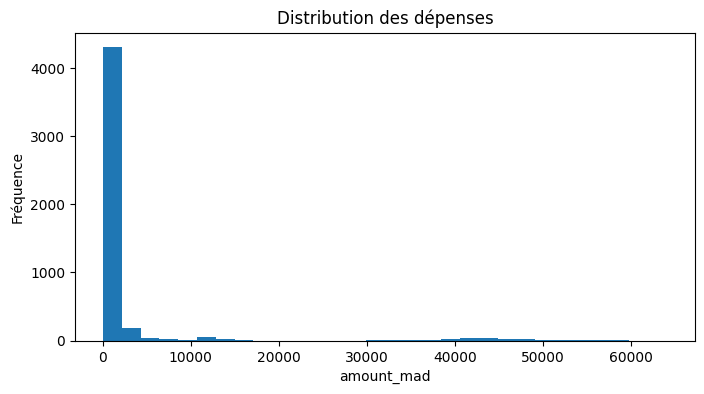

In [8]:
# Cette cellule visualise les distributions principales.

plt.figure(figsize=(8, 4))
plt.hist(df_vente["total_eur"].dropna(), bins=30)
plt.title("Distribution du CA par facture")
plt.xlabel("total_eur")
plt.ylabel("Fréquence")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_depence["amount_mad"].dropna(), bins=30)
plt.title("Distribution des dépenses")
plt.xlabel("amount_mad")
plt.ylabel("Fréquence")
plt.show()

## Interprétation
Ces histogrammes montrent la forme générale des distributions.

À commenter :
- une forte concentration sur les faibles montants accompagnée d’une longue traîne est typique des données financières ;
- cela signifie que quelques opérations pèsent beaucoup plus que la majorité ;
- dans ce cas, les moyennes doivent être interprétées avec prudence.

Corrélations

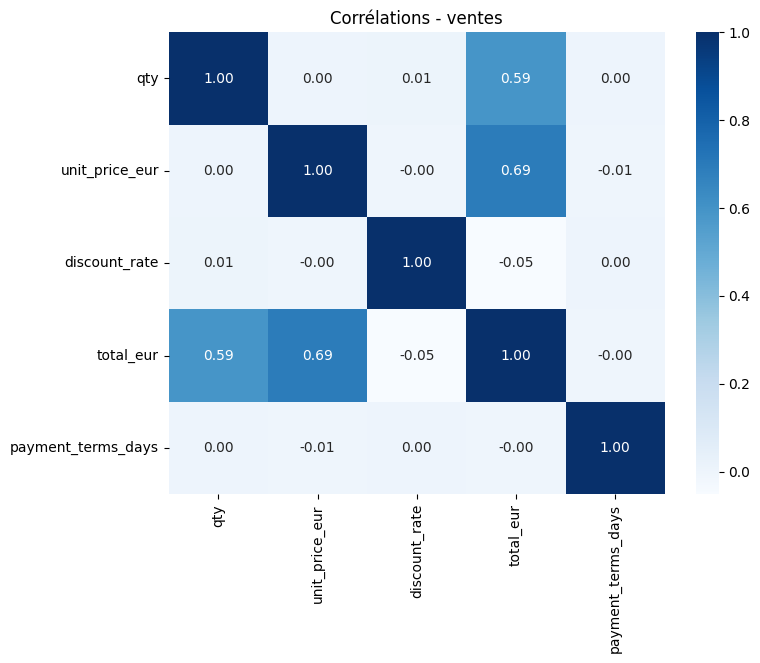

In [10]:
# Cette cellule affiche la matrice de corrélation des variables numériques de vente.

corr = df_vente.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Corrélations - ventes")
plt.show()

## Interprétation
La matrice de corrélation mesure l’intensité des relations linéaires entre variables.

À commenter :
- une forte corrélation positive indique que deux variables évoluent ensemble ;
- une corrélation faible indique une relation linéaire peu marquée ;
- il faut rappeler qu’une corrélation n’implique pas une causalité.

Saisonnalité

,month_num,total_eur
0,1,1852397.15
1,2,1547555.58
2,3,2001626.10
3,4,1991668.08
4,5,1986998.79
5,6,1735177.72
6,7,1861320.30
7,8,1798118.88
8,9,1766860.07
9,10,2218595.59


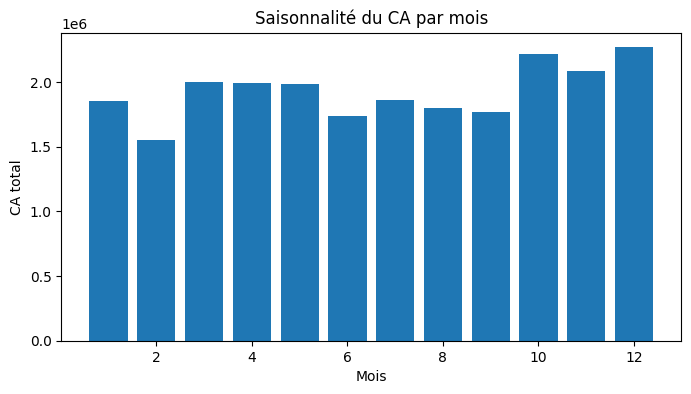

In [13]:
# Cette cellule mesure le CA par mois calendaire.

df_vente["month_num"] = df_vente["date"].dt.month
ca_saisonnier = df_vente.groupby("month_num", as_index=False)["total_eur"].sum()

display(ca_saisonnier)

plt.figure(figsize=(8, 4))
plt.bar(ca_saisonnier["month_num"], ca_saisonnier["total_eur"])
plt.title("Saisonnalité du CA par mois")
plt.xlabel("Mois")
plt.ylabel("CA total")
plt.show()

## Interprétation
Cette analyse permet de repérer les périodes fortes et faibles de l’activité.

À commenter :
- des pics récurrents peuvent traduire une saisonnalité commerciale ;
- des creux peuvent révéler des périodes structurellement moins actives ;
- cela aide à planifier les objectifs et ressources commerciales.

CA par catégorie produit

In [16]:
# Cette cellule calcule le chiffre d'affaires par catégorie produit.

vente_produit_cat = df_vente.merge(
    df_produit[["product_id", "category"]],
    on="product_id",
    how="left"
)

ca_categorie = (
    vente_produit_cat.groupby("category", as_index=False)["total_eur"]
    .sum()
    .sort_values("total_eur", ascending=False)
)

display(ca_categorie)

,category,total_eur
1,Hardware,8898908.54
2,Service,6502272.04
4,Training,3479624.80
0,Consulting,2225108.70
3,Subscription,2005043.56


## Interprétation
Cette analyse montre quelles catégories portent le plus l’activité.

À commenter :
- les catégories dominantes constituent le cœur du business ;
- les catégories faibles peuvent représenter des relais de croissance ou des segments secondaires ;
- cela aide à orienter l’effort commercial et marketing.

Test t : Q4 vs autres

In [17]:
# Cette cellule compare le CA moyen mensuel du T4 au reste de l'année.

df_vente["month"] = df_vente["date"].dt.to_period("M").dt.to_timestamp()
ca_month = df_vente.groupby("month", as_index=False)["total_eur"].sum()
ca_month["quarter"] = ca_month["month"].dt.quarter

q4 = ca_month.loc[ca_month["quarter"] == 4, "total_eur"]
not_q4 = ca_month.loc[ca_month["quarter"] != 4, "total_eur"]

t_stat, p_value = ttest_ind(q4, not_q4, equal_var=False, nan_policy="omit")

print("t-stat :", t_stat)
print("p-value :", p_value)

t-stat : 9.221500822617102
p-value : 4.348215407039965e-12


## Interprétation
Ce test statistique vérifie si le T4 présente un niveau d’activité significativement différent.

À commenter :
- si la p-value est inférieure à 0,05, on conclut à une différence significative ;
- sinon, l’écart observé peut être attribué à la variabilité naturelle ;
- ce test complète l’analyse visuelle de saisonnalité.

Test Chi²

In [19]:
# Cette cellule teste la dépendance entre département et type de dépense.

cont_table = pd.crosstab(df_depence["department"], df_depence["type"])
chi2, p, dof, expected = chi2_contingency(cont_table)

print("Chi2 :", chi2)
print("p-value :", p)
print("dof :", dof)

Chi2 : 2823.0634582876023
p-value : 0.0
dof : 5


## Interprétation
Le test du Chi² permet de vérifier si la structure des charges dépend du département.

À commenter :
- une p-value inférieure à 0,05 indique une dépendance significative ;
- cela signifie que certains départements ont une structure de coûts spécifique ;
- cette information peut alimenter le pilotage budgétaire.

## Conclusion
Ce notebook a permis :
- de décrire la structure statistique des données,
- d’identifier les comportements commerciaux marquants,
- de caractériser la concentration clients et produits,
- et de tester quelques hypothèses simples sur les ventes et les dépenses.